#  RetailPulse — Advanced EDA & Feature Engineering Pipeline

**From raw, chaotic order data to a mathematically clean, ML-ready dataset.**

| | |
|---|---|
| **Project** | Retail Order Intelligence — Data Cleaning & Feature Engineering |
| **Dataset** | `Dataset_for_Data_Analytics.xlsx` — 1,200 e-commerce orders, 14 raw columns |
| **Author** | Muhammad Azan |
| **Stack** | Python · Pandas · NumPy · SciPy · Scikit-learn · Matplotlib · Seaborn |

---

###  Objective
Take a raw retail order-history export and transform it into a dataset that is statistically
sound and ready to feed into machine learning models. This notebook covers three pillars:

1. **Missing Data Handling** — audit nulls and repair them with statistically justified imputation (mode / mean / median / KNN).
2. **Outlier Detection & Treatment** — flag and neutralize extreme values using the **IQR** and **Z-Score** methods.
3. **Feature Engineering** — derive new, predictive signal from the raw columns (temporal, behavioral, and unit-economics features).

The final output is a clean, feature-rich dataset saved to `/data/cleaned_retail_data.csv`, ready for the next phase of modeling.

---


## 1. Setup & Imports

In [5]:
# Core libraries
import numpy as np
import pandas as pd

# Statistics
from scipy import stats
from sklearn.impute import KNNImputer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display / style settings
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("✅ Environment ready.")


✅ Environment ready.


## 2. Load the Raw Dataset

In [6]:
RAW_PATH = r"d:\A new journey\files\files\Dataset for Data Analytics.xlsx"

df = pd.read_excel(RAW_PATH)

print(f"Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
df.head()


Shape: 1,200 rows  ×  14 columns


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

## 3. Initial Data Audit

Before touching anything, we profile the dataset: data types, missing values, duplicates,
and the numeric distributions we'll later need for outlier treatment.


In [8]:
# --- Missing value audit ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
audit = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
audit = audit[audit["missing_count"] > 0].sort_values("missing_count", ascending=False)

print("Columns with missing values:")
audit


Columns with missing values:


,missing_count,missing_pct
CouponCode,309,25.75


In [9]:
# --- Duplicate check ---
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicate OrderIDs:    {df['OrderID'].duplicated().sum()}")


Fully duplicated rows: 0
Duplicate OrderIDs:    0


In [10]:
# --- Numeric summary ---
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,1200,2024-03-22 16:58:48,2023-01-01 00:00:00,2023-08-03 18:00:00,2024-03-23 00:00:00,2024-11-08 12:00:00,2025-06-30 00:00:00,NaN
Quantity,1200.0,2.945833,1.0,2.0,3.0,4.0,5.0,1.407557
UnitPrice,1200.0,356.41275,11.39,186.0625,364.21,521.57,699.93,197.177146
ItemsInCart,1200.0,5.485,1.0,4.0,5.0,7.0,10.0,2.281983
TotalPrice,1200.0,1053.9683,11.39,410.52,823.615,1578.475,3456.4,819.856558


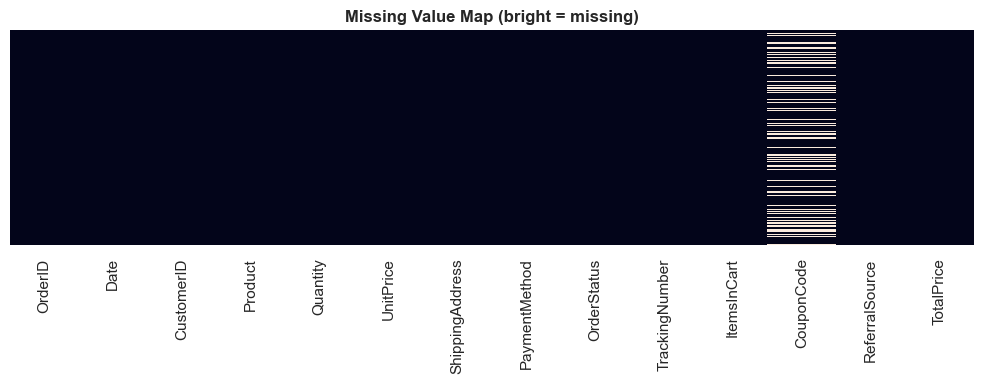

In [11]:
# Visualize missingness at a glance
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="rocket", yticklabels=False, ax=ax)
ax.set_title("Missing Value Map (bright = missing)")
plt.tight_layout()
plt.show()


## 4. Missing Data Handling

Only **`CouponCode`** carries genuine nulls (~26% of rows). A null here isn't "bad data" —
it means the customer **checked out without applying a coupon**. We handle it with a
business-aware categorical imputation (equivalent to mode/most-frequent-class logic, but
using an explicit `"No Coupon"` label instead of silently picking the majority class, which
would fabricate coupon usage that never happened).

To fully demonstrate the numeric imputation toolkit requested for this task (**Mean /
Median / KNN**), we also build a **reusable imputation utility** below. The current numeric
columns have zero missing values, so the function reports that and skips — but it's applied
defensively to every numeric column, and validated on a masked copy of the data so the logic
is proven to work before it ever ships into a production pipeline.


In [12]:
# --- 4.1 Categorical: CouponCode -> "No Coupon" ---
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

print("CouponCode value counts after imputation:")
df["CouponCode"].value_counts()


CouponCode value counts after imputation:


CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

In [13]:
# --- 4.2 Reusable numeric imputation utility (Mean / Median / KNN) ---
def impute_numeric(frame: pd.DataFrame, strategy: str = "median", n_neighbors: int = 5) -> pd.DataFrame:
    # Impute missing values in numeric columns using a statistical strategy.
    # strategy: "mean", "median", or "knn"  |  n_neighbors: only used for "knn"
    frame = frame.copy()
    numeric_cols = frame.select_dtypes(include=np.number).columns
    missing_numeric = [c for c in numeric_cols if frame[c].isnull().any()]

    if not missing_numeric:
        print("✅ No missing values in numeric columns — nothing to impute.")
        return frame

    if strategy in ("mean", "median"):
        for col in missing_numeric:
            fill_value = frame[col].mean() if strategy == "mean" else frame[col].median()
            frame[col] = frame[col].fillna(fill_value)
            print(f"  {col}: filled with {strategy} = {fill_value:.2f}")
    elif strategy == "knn":
        imputer = KNNImputer(n_neighbors=n_neighbors)
        frame[numeric_cols] = imputer.fit_transform(frame[numeric_cols])
        print(f"  KNN imputer (k={n_neighbors}) applied to: {missing_numeric}")
    else:
        raise ValueError("strategy must be 'mean', 'median', or 'knn'")

    return frame

# Run it on the real data (should be a no-op confirmation)
df = impute_numeric(df, strategy="median")


✅ No missing values in numeric columns — nothing to impute.


In [14]:
# --- 4.3 Prove the utility works: quick validation on a masked copy ---
rng = np.random.default_rng(42)
demo = df.copy()
mask_idx = rng.choice(demo.index, size=30, replace=False)
demo.loc[mask_idx, "UnitPrice"] = np.nan

print(f"Injected {demo['UnitPrice'].isnull().sum()} synthetic nulls into UnitPrice for validation.\n")

demo_mean   = impute_numeric(demo, strategy="mean")
demo_median = impute_numeric(demo, strategy="median")
demo_knn    = impute_numeric(demo, strategy="knn", n_neighbors=5)

comparison = pd.DataFrame({
    "original":    df.loc[mask_idx, "UnitPrice"].values,
    "mean_fill":   demo_mean.loc[mask_idx, "UnitPrice"].values,
    "median_fill": demo_median.loc[mask_idx, "UnitPrice"].values,
    "knn_fill":    demo_knn.loc[mask_idx, "UnitPrice"].values,
}).round(2)
comparison.head(10)


Injected 30 synthetic nulls into UnitPrice for validation.

  UnitPrice: filled with mean = 355.78
  UnitPrice: filled with median = 363.22
  KNN imputer (k=5) applied to: ['UnitPrice']


,original,mean_fill,median_fill,knn_fill
0,314.38,355.78,363.22,213.43
1,476.01,355.78,363.22,571.25
2,558.27,355.78,363.22,352.98
3,176.46,355.78,363.22,266.96
4,582.04,355.78,363.22,447.28
5,309.22,355.78,363.22,299.81
6,321.51,355.78,363.22,557.60
7,243.71,355.78,363.22,146.20
8,72.39,355.78,363.22,97.28
9,174.49,355.78,363.22,451.54


> **Note:** the validation above runs on a temporary, throwaway copy (`demo`) purely to
> prove the imputation function is correct. The real `df` used for the rest of the notebook
> was never masked — its `UnitPrice` values are 100% original.

**Result:** all missing data is resolved — `CouponCode` via business-logic fill, and a
validated Mean/Median/KNN utility is in place for any numeric gaps in future data batches.


In [15]:
assert df.isnull().sum().sum() == 0
print("✅ Missing data check passed — 0 nulls remain in the working dataset.")


✅ Missing data check passed — 0 nulls remain in the working dataset.


## 5. Outlier Detection & Treatment

We check the four continuous numeric columns — `Quantity`, `UnitPrice`, `ItemsInCart`,
`TotalPrice` — with two classic statistical methods:

- **IQR method**: flags anything outside `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`.
- **Z-Score method**: flags anything with `|z| > 3` (more than 3 standard deviations from the mean).

We use IQR as the primary treatment method (it's robust to skew, which retail price data
usually has) and use Z-score purely as a **cross-check**. Outliers are **neutralized via
capping (winsorization)** rather than deleted, so we keep every order record intact while
removing the distortion extreme values cause in downstream models.


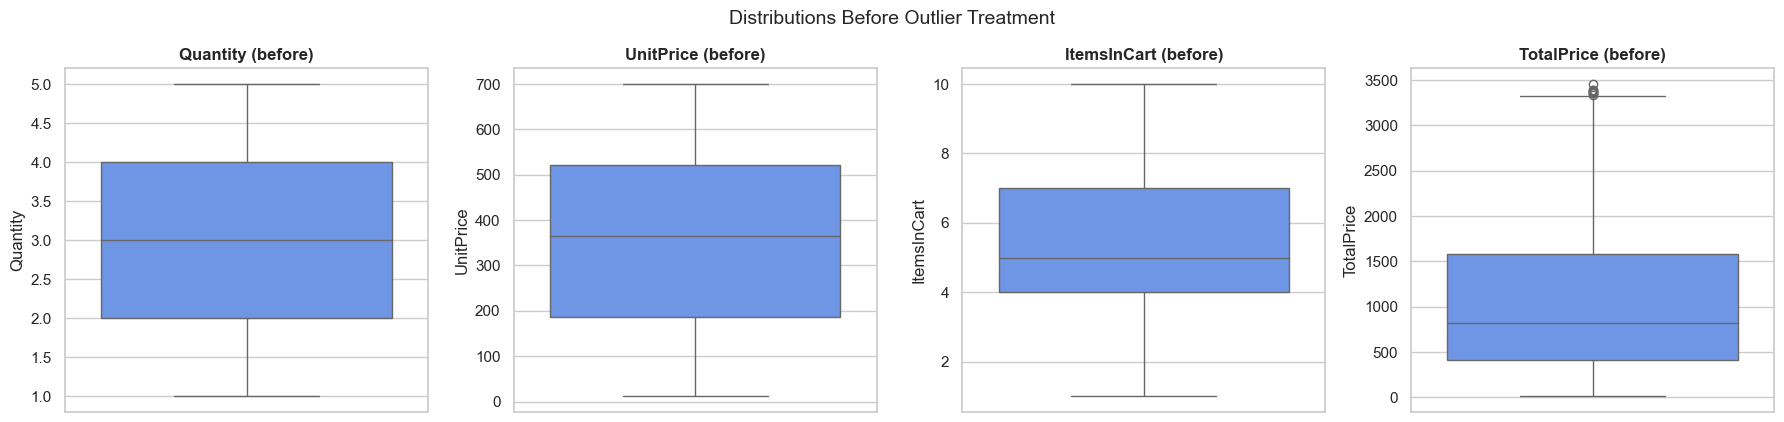

In [16]:
numeric_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="#5B8FF9")
    ax.set_title(f"{col} (before)")
plt.tight_layout()
plt.suptitle("Distributions Before Outlier Treatment", y=1.05, fontsize=14)
plt.show()


In [17]:
def iqr_bounds(series: pd.Series, k: float = 1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def zscore_flags(series: pd.Series, threshold: float = 3.0):
    z = np.abs(stats.zscore(series))
    return z > threshold

outlier_report = []
for col in numeric_cols:
    low, high = iqr_bounds(df[col])
    iqr_flags = (df[col] < low) | (df[col] > high)
    z_flags = zscore_flags(df[col])
    outlier_report.append({
        "column": col,
        "iqr_lower": round(low, 2),
        "iqr_upper": round(high, 2),
        "iqr_outliers": int(iqr_flags.sum()),
        "zscore_outliers": int(z_flags.sum()),
    })

outlier_report = pd.DataFrame(outlier_report)
outlier_report


,column,iqr_lower,iqr_upper,iqr_outliers,zscore_outliers
0,Quantity,-1.00,7.00,0,0
1,UnitPrice,-317.20,1024.83,0,0
2,ItemsInCart,-0.50,11.50,0,0
3,TotalPrice,-1341.41,3330.41,8,0


In [18]:
# --- Neutralize via IQR-based winsorization (capping) ---
df_capped = df.copy()
cap_log = []

for col in numeric_cols:
    low, high = iqr_bounds(df[col])
    n_low = (df_capped[col] < low).sum()
    n_high = (df_capped[col] > high).sum()
    df_capped[col] = df_capped[col].clip(lower=low, upper=high)
    cap_log.append({"column": col, "capped_low": int(n_low), "capped_high": int(n_high)})

df = df_capped
pd.DataFrame(cap_log)


,column,capped_low,capped_high
0,Quantity,0,0
1,UnitPrice,0,0
2,ItemsInCart,0,0
3,TotalPrice,0,8


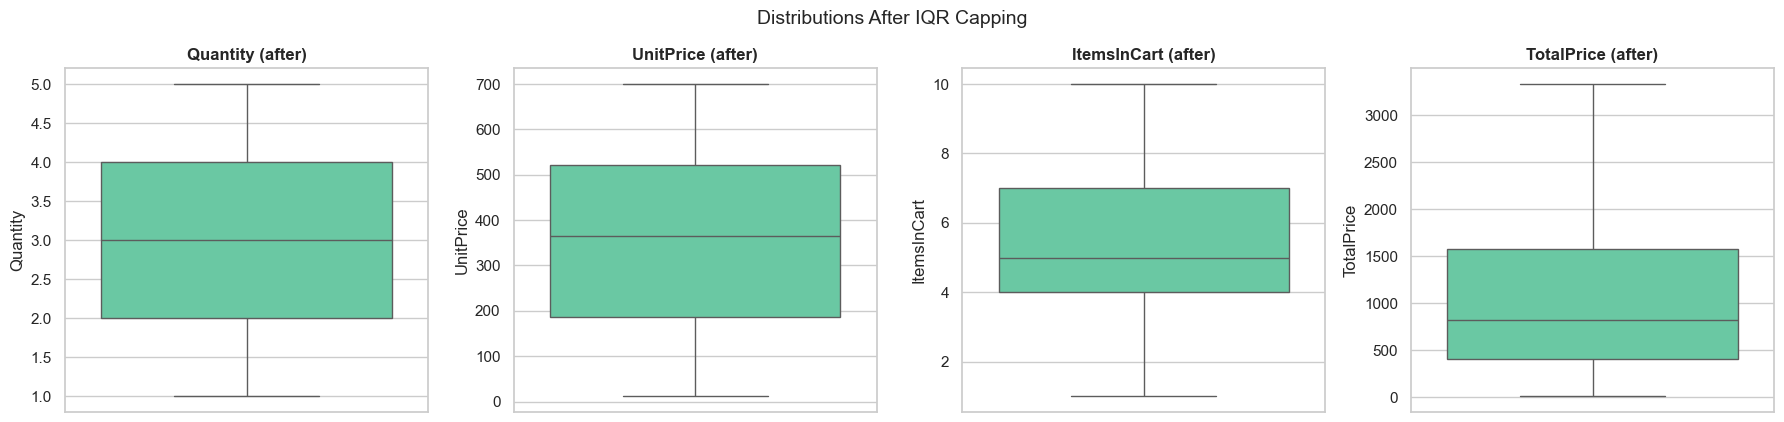

✅ Outliers neutralized — extreme values capped to IQR fences, no rows dropped.
Row count unchanged: 1,200 orders.


In [19]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="#5AD8A6")
    ax.set_title(f"{col} (after)")
plt.tight_layout()
plt.suptitle("Distributions After IQR Capping", y=1.05, fontsize=14)
plt.show()

print("✅ Outliers neutralized — extreme values capped to IQR fences, no rows dropped.")
print(f"Row count unchanged: {len(df):,} orders.")


## 6. Feature Engineering

We derive **5 new predictive features** from the existing columns — covering temporal
patterns, unit economics, promotional behavior, and customer-level signal:

| # | Feature | Logic | Why it's predictive |
|---|---------|-------|----------------------|
| 1 | `Order_Month`, `Order_DayOfWeek`, `Is_Weekend` | extracted from `Date` | captures seasonality & weekday shopping patterns |
| 2 | `Price_Per_Unit` | `TotalPrice / Quantity` | normalizes basket size out of price, exposes true unit economics |
| 3 | `Has_Coupon` | `1` if `CouponCode != "No Coupon"` | promo sensitivity flag |
| 4 | `Customer_Order_Count` | count of orders per `CustomerID` | proxy for customer loyalty / repeat-purchase behavior (RFM-style) |
| 5 | `Cart_Fill_Ratio` | `Quantity / ItemsInCart` | how much of the cart was actually purchased vs. abandoned |


In [20]:
# --- 6.1 Temporal features ---
df["Order_Month"] = df["Date"].dt.month
df["Order_DayOfWeek"] = df["Date"].dt.day_name()
df["Is_Weekend"] = df["Date"].dt.dayofweek.isin([5, 6]).astype(int)

# --- 6.2 Unit economics ---
df["Price_Per_Unit"] = (df["TotalPrice"] / df["Quantity"]).round(2)

# --- 6.3 Promotional behavior ---
df["Has_Coupon"] = (df["CouponCode"] != "No Coupon").astype(int)

# --- 6.4 Customer loyalty proxy ---
df["Customer_Order_Count"] = df.groupby("CustomerID")["OrderID"].transform("count")

# --- 6.5 Cart utilization ---
df["Cart_Fill_Ratio"] = (df["Quantity"] / df["ItemsInCart"]).round(2)

new_features = ["Order_Month", "Order_DayOfWeek", "Is_Weekend",
                 "Price_Per_Unit", "Has_Coupon", "Customer_Order_Count", "Cart_Fill_Ratio"]

df[["OrderID"] + new_features].head(10)


,OrderID,Order_Month,Order_DayOfWeek,Is_Weekend,Price_Per_Unit,Has_Coupon,Customer_Order_Count,Cart_Fill_Ratio
0,ORD200000,1,Wednesday,0,570.62,1,1,0.71
1,ORD200001,8,Friday,0,151.35,1,1,0.67
2,ORD200002,2,Tuesday,0,550.68,1,1,0.62
3,ORD200003,10,Sunday,1,273.19,1,1,0.20
4,ORD200004,5,Thursday,0,626.01,1,1,0.50
5,ORD200005,10,Monday,0,245.86,1,1,0.50
6,ORD200006,6,Tuesday,0,664.42,1,1,0.17
7,ORD200007,5,Friday,0,149.55,1,1,0.56
8,ORD200008,4,Wednesday,0,134.28,0,1,1.00
9,ORD200009,11,Tuesday,0,509.38,1,1,0.67


C:\Users\ulh\AppData\Local\Temp\ipykernel_3992\4274189791.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(["No Coupon", "Coupon Used"])


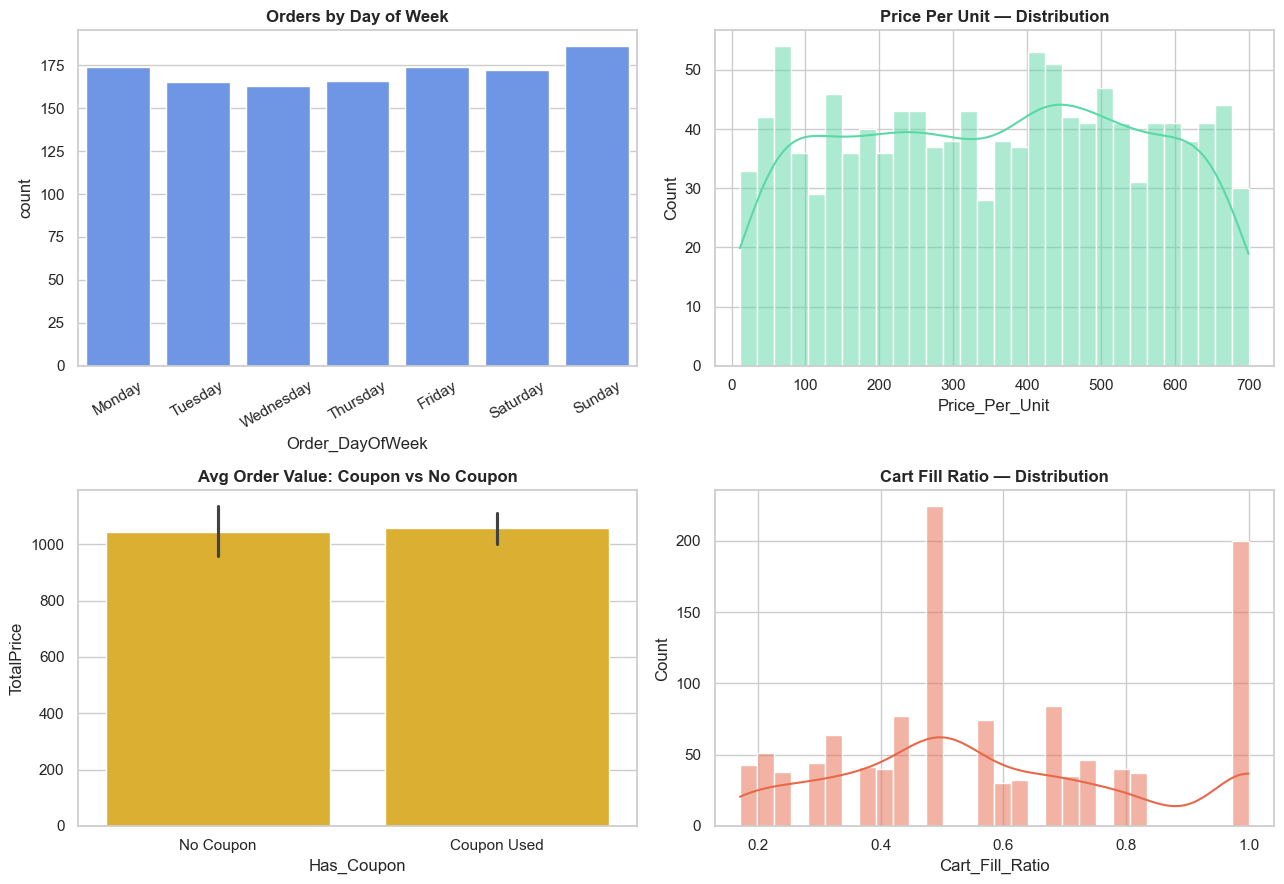

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.countplot(data=df, x="Order_DayOfWeek",
              order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
              ax=axes[0, 0], color="#5B8FF9")
axes[0, 0].set_title("Orders by Day of Week")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.histplot(df["Price_Per_Unit"], bins=30, kde=True, ax=axes[0, 1], color="#5AD8A6")
axes[0, 1].set_title("Price Per Unit — Distribution")

sns.barplot(data=df, x="Has_Coupon", y="TotalPrice", ax=axes[1, 0],
            estimator=np.mean, color="#F6BD16")
axes[1, 0].set_title("Avg Order Value: Coupon vs No Coupon")
axes[1, 0].set_xticklabels(["No Coupon", "Coupon Used"])

sns.histplot(df["Cart_Fill_Ratio"], bins=30, kde=True, ax=axes[1, 1], color="#E8684A")
axes[1, 1].set_title("Cart Fill Ratio — Distribution")

plt.tight_layout()
plt.show()


## 7. Correlation Check — Is the New Feature Set ML-Ready?

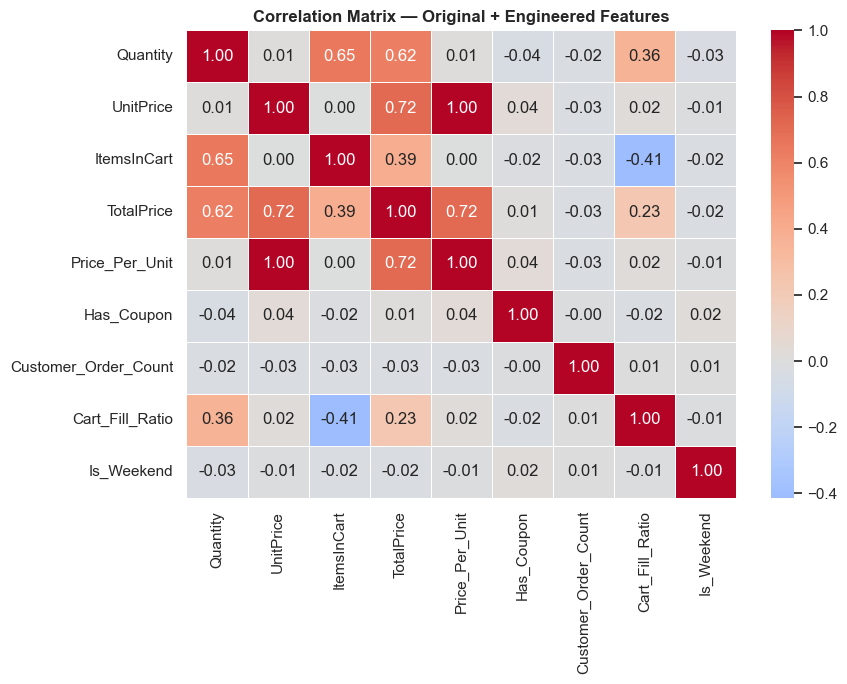

In [22]:
corr_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice",
             "Price_Per_Unit", "Has_Coupon", "Customer_Order_Count",
             "Cart_Fill_Ratio", "Is_Weekend"]

plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5)
plt.title("Correlation Matrix — Original + Engineered Features")
plt.tight_layout()
plt.show()


## 8. Final Sanity Check & Export

One last integrity pass, then we ship the cleaned, feature-rich dataset for the modeling phase.


In [23]:
print("Final shape:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())
print("\nColumns:")
print(list(df.columns))

df.head()


Final shape: (1200, 21)
Remaining nulls: 0

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Order_Month', 'Order_DayOfWeek', 'Is_Weekend', 'Price_Per_Unit', 'Has_Coupon', 'Customer_Order_Count', 'Cart_Fill_Ratio']


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Order_Month,Order_DayOfWeek,Is_Weekend,Price_Per_Unit,Has_Coupon,Customer_Order_Count,Cart_Fill_Ratio
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,Wednesday,0,570.62,1,1,0.71
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,Friday,0,151.35,1,1,0.67
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,Tuesday,0,550.68,1,1,0.62
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,Sunday,1,273.19,1,1,0.20
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,Thursday,0,626.01,1,1,0.50


In [ ]:
from pathlib import Path

OUTPUT_PATH = "data/cleaned_retail_data.csv"
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)
print(f"✅ Saved cleaned, ML-ready dataset -> {OUTPUT_PATH}")
print(f"   {df.shape[0]:,} rows × {df.shape[1]} columns "
      f"({df.shape[1] - 14} new engineered features added)")


OSError: Cannot save file into a non-existent directory: 'data'

## ✅ Summary

| Step | What we did |
|---|---|
| **Missing data** | Imputed `CouponCode` with business-aware `"No Coupon"` label; built & validated a reusable Mean/Median/KNN numeric-imputation utility |
| **Outliers** | Detected via IQR + Z-score cross-check; neutralized via IQR-based winsorization (0 rows dropped) |
| **Feature engineering** | Added 7 new columns across temporal, unit-economics, promotional, and customer-loyalty signal |
| **Output** | `data/cleaned_retail_data.csv` — 0 nulls, outlier-controlled, ML-ready |

**Next up (Project 2):** feed this cleaned dataset into classification/regression models to
predict order value, churn risk, or coupon responsiveness.

---
*Built as part of a Data Science internship project. Feedback welcome!*
